# PMT Semigaussian fit

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
import os

import imp
import eventlist_fitting
imp.reload(eventlist_fitting)

<module 'eventlist_fitting' from '/home/gamma/workspace/gammalib/gammaanlysis/eventlist_fitting.py'>

In [2]:
input_file = "/home/gamma/workspace/gammalib/gammaanlysis/real_params/alldata_semigaussian_shaper_PMT.txt"  # Sostituire con il percorso del file di input
output_file = "/home/gamma/workspace/gammalib/gammaanlysis/real_params/alldata_semigaussian_shaper_PMT.h5"  # Sostituire con il percorso desiderato del file CSV

In [10]:
evlist = eventlist_fitting.Eventlist_fitting()
# convert in HDF5
if not os.path.exists(output_file):
    evlist.to_h5(input_file, output_file, fName="semigaussian_shaper", detector='PMT')
# Read file
df = evlist.read_fitresults(output_file)

print(df.attrs)
df.head()

Reading fit results from /home/gamma/workspace/gammalib/gammaanlysis/real_params/alldata_semigaussian_shaper_PMT.h5...
{'detector': 'PMT', 'fName': 'semigaussian_shaper'}


,folder_id,file_id,wfID,pkID,chi2,curveMax,integral,dof,arg__y0,arg__t0,arg__n,arg__A,arg__tau,satCheck
0,0,0,9,0,3.809695,564.106977,22486.099567,233.0,95.642439,8.459007,1.000000,1273.445752,17.655954,False
1,0,0,12,0,1.653705,256.113882,6863.410144,133.0,100.064778,8.459148,1.000000,424.248260,16.259432,False
2,0,0,13,0,1.420104,233.951528,6617.988219,155.0,94.568186,9.519799,1.000000,378.884362,17.523462,False
3,0,0,23,0,1.529221,505.651404,19262.488503,202.0,105.607872,6.890743,1.075368,1121.791571,17.179268,False
4,0,0,39,0,1.953911,321.209653,11263.555907,162.0,95.038587,8.149695,1.000000,615.024244,18.346654,False


In [11]:
df = evlist.get_args_fitted()
df.head()

,chi2,curveMax,integral,dof,arg__y0,arg__t0,arg__n,arg__A,arg__tau
0,3.809695,564.106977,22486.099567,233.0,95.642439,8.459007,1.000000,1273.445752,17.655954
1,1.653705,256.113882,6863.410144,133.0,100.064778,8.459148,1.000000,424.248260,16.259432
2,1.420104,233.951528,6617.988219,155.0,94.568186,9.519799,1.000000,378.884362,17.523462
3,1.529221,505.651404,19262.488503,202.0,105.607872,6.890743,1.075368,1121.791571,17.179268
4,1.953911,321.209653,11263.555907,162.0,95.038587,8.149695,1.000000,615.024244,18.346654


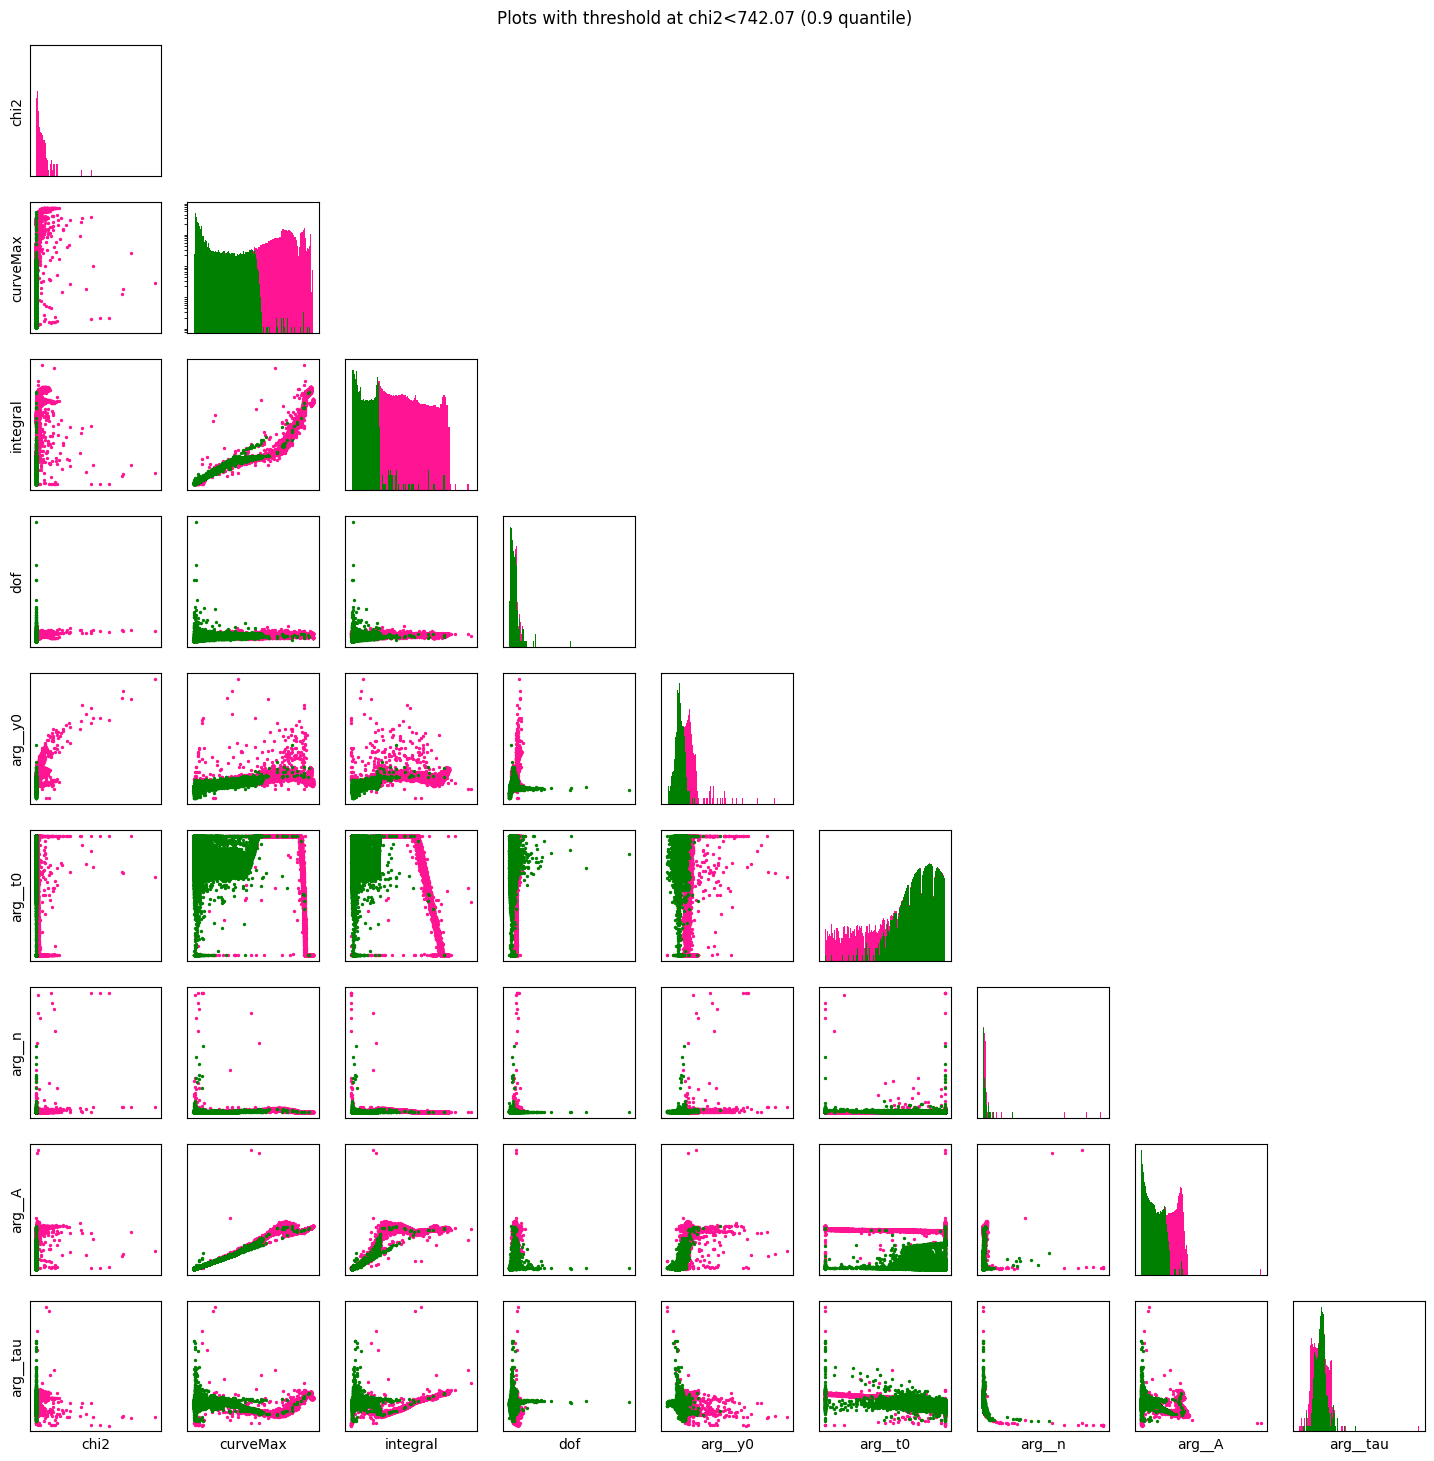

In [12]:
evlist.make_plot(quantile_thresh=0.9)

Detector: PMT
Function semigaussian_shaper with parameters: ['arg__y0', 'arg__t0', 'arg__n', 'arg__A', 'arg__tau']
Saturation check: False
0 waveforms have been removed for dof < 0 or chi2 == inf.
163018 waveforms have been removed for Cutoff above chi2 values of 6.576868902481031, which is the 0.75 quantile.


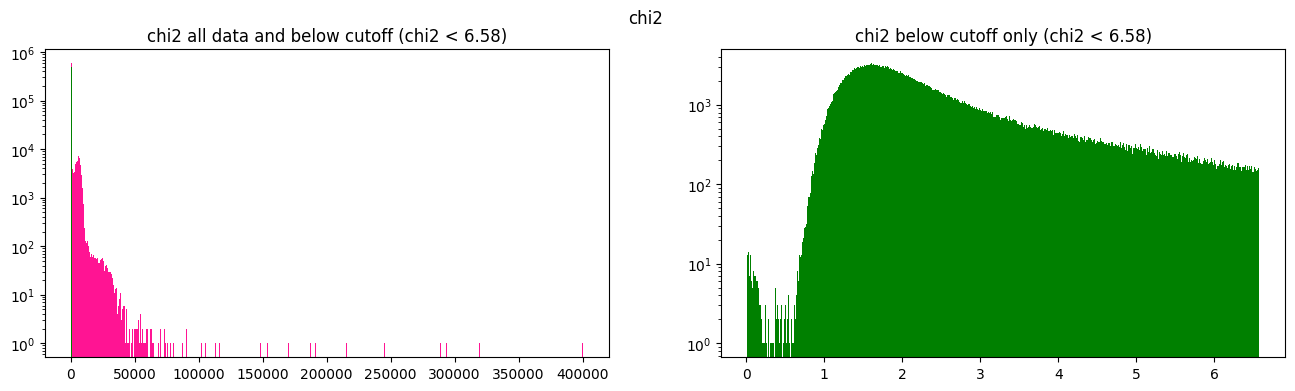

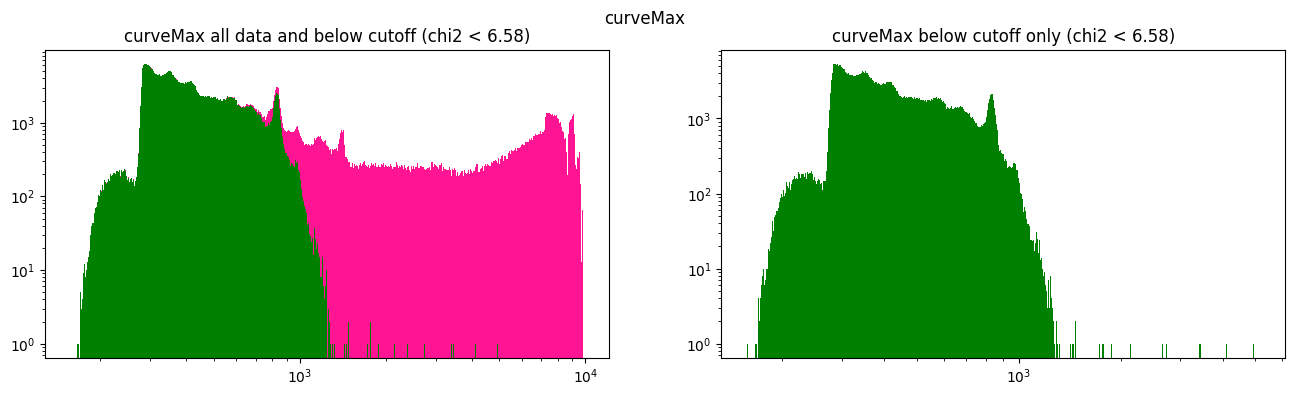

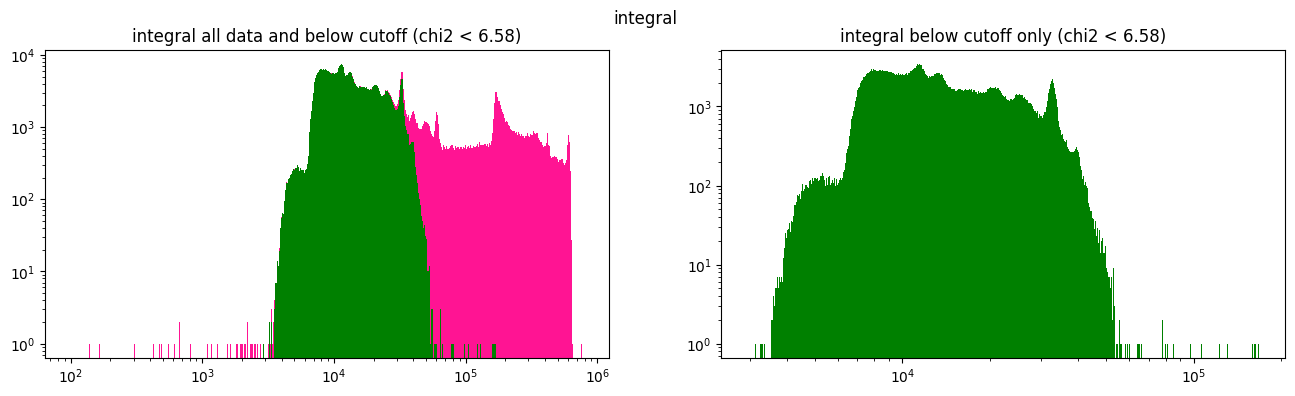

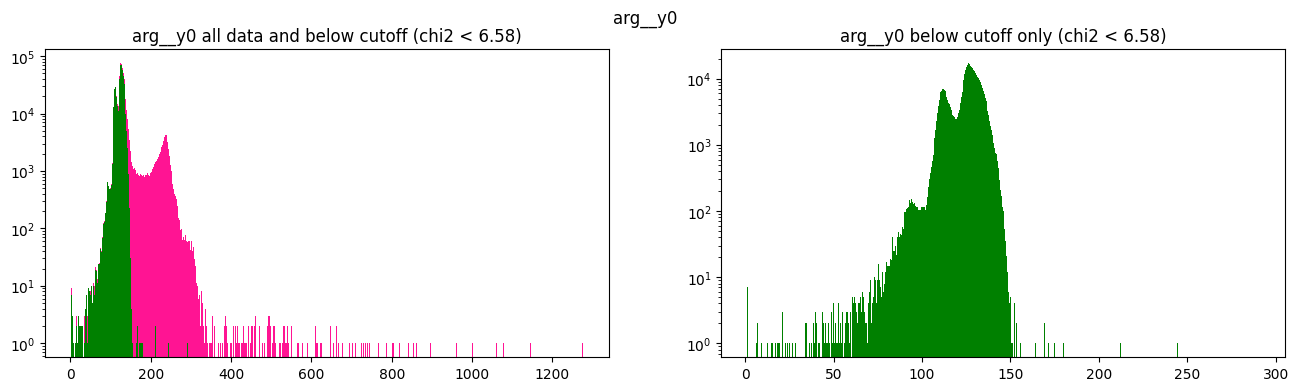

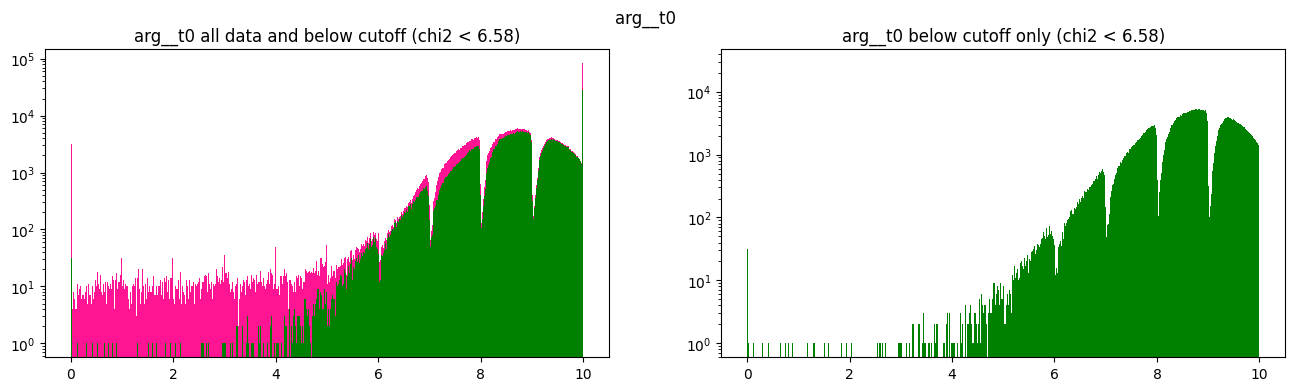

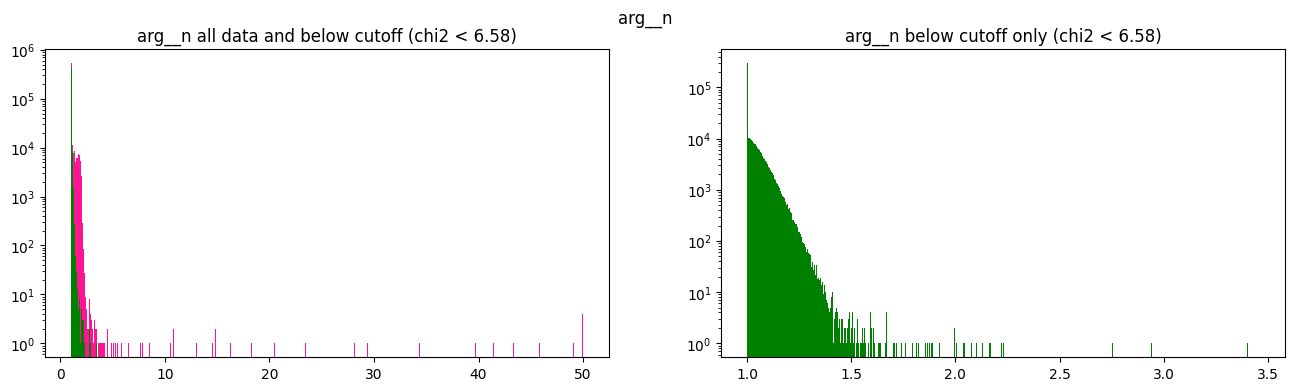

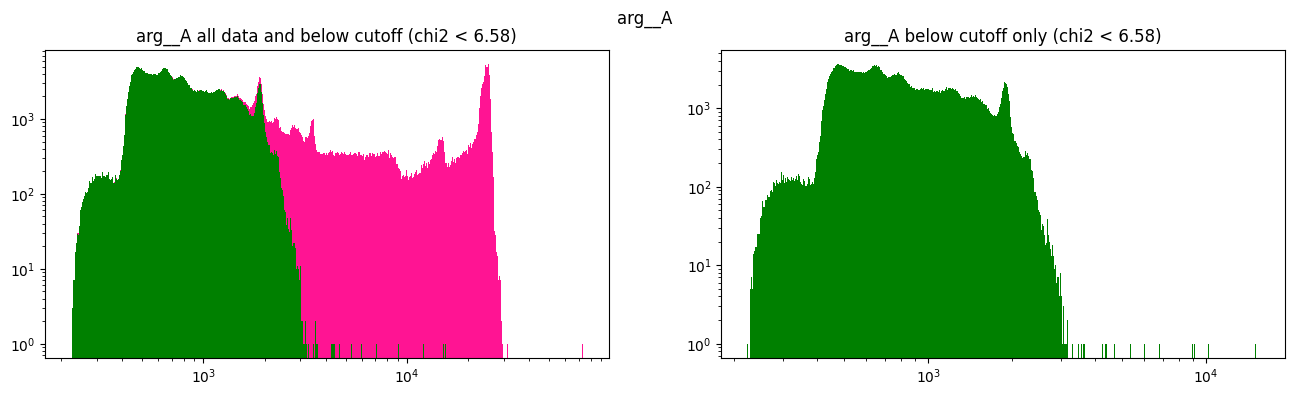

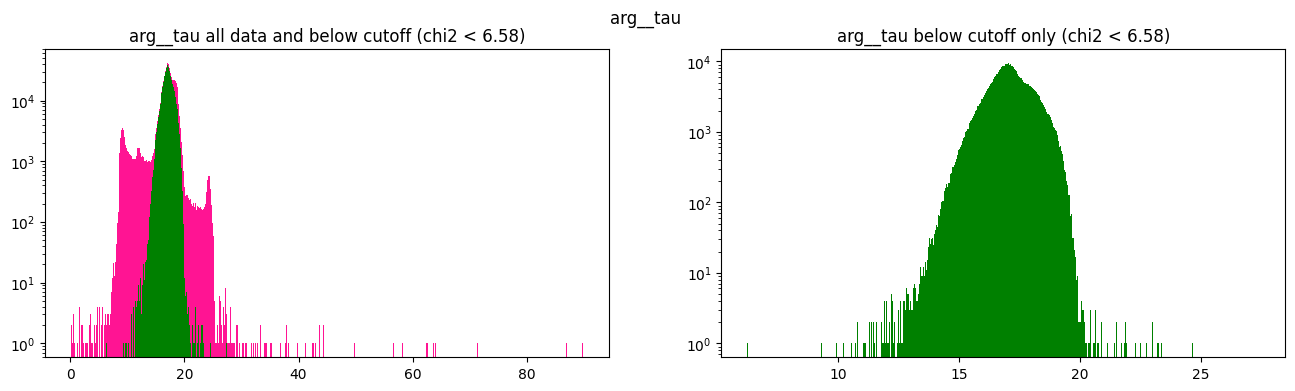

In [14]:
evlist.params_analysis(False, log=True, quantile_thresh=0.75)

In [10]:
# Filtra solo le colonne con "arg" nel nome
arg_columns = [col for col in df.columns if "arg" in col]
df_arg = df[arg_columns]
df_arg.describe()

,arg__y0,arg__t0,arg__n,arg__A,arg__tau
count,652073.000000,652073.000000,652073.000000,652073.000000,652073.000000
mean,137.481732,8.666829,1.080401,3766.741384,16.771319
std,33.602577,1.165627,0.275956,6892.729373,2.224364
min,1.026000,0.001000,1.000000,223.094571,0.049068
25%,123.337049,8.122239,1.000000,604.546443,16.410654
50%,128.319116,8.731594,1.000000,941.951639,17.117280
75%,134.909617,9.481386,1.049756,1952.973742,17.927064
max,1276.404516,10.000000,50.000000,73344.395353,89.889212


In [11]:
# Calcolo dei limiti IQR
Q1 = df_arg.describe().loc['25%']
Q3 = df_arg.describe().loc['75%']
IQR = Q3 - Q1
# Limiti inferiori e superiori
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrare le righe non outlier
df_arg = df_arg[((df_arg > lower_bound) & (df_arg < upper_bound)).all(axis=1)]
df_arg.describe()

,arg__y0,arg__t0,arg__n,arg__A,arg__tau
count,511605.000000,511605.000000,511605.000000,511605.000000,511605.000000
mean,125.926828,8.732753,1.016043,1080.394964,17.280082
std,8.408871,0.766425,0.029023,700.444842,0.852717
min,105.979596,6.084001,1.000000,228.220296,14.145777
25%,121.551677,8.284313,1.000000,581.752695,16.694948
50%,126.942865,8.735236,1.000000,809.131042,17.196112
75%,131.548435,9.363933,1.021275,1367.231913,17.869966
max,152.243460,10.000000,1.124387,3975.566357,20.196665


In [12]:
15*8e-9

1.2000000000000002e-07

---

In [30]:
arg_data = df[arg_columns]
# Convertilo in un array numpy
arg_array = arg_data.to_numpy()

In [31]:
# Calcola la media e la matrice di covarianza
mean = np.mean(arg_array, axis=0)
cov = np.cov(arg_array, rowvar=False)
# Crea una distribuzione multivariata
multivariate_dist = multivariate_normal(mean=mean, cov=cov)

In [10]:
# Esempio: calcolo della probabilità per un punto (prima riga dei dati)
example_point = arg_array[0]
probability = multivariate_dist.pdf(example_point)

print("Media:\n", mean, "\n")
print("Matrice di covarianza:\n", cov, "\n")
print(f"Probabilità del punto {example_point}: {probability}")

Media:
 [1.37481732e+02 8.66682947e+00 1.08040147e+00 3.76674138e+03
 1.67713187e+01] 

Matrice di covarianza:
 [[ 1.12913321e+03  2.68961885e+00  5.25290737e+00  2.18826097e+05
  -4.08377689e+01]
 [ 2.68961885e+00  1.35868549e+00  6.04129311e-02  2.02311084e+02
  -1.37002672e+00]
 [ 5.25290737e+00  6.04129311e-02  7.61515103e-02  1.05317881e+03
  -4.00221869e-01]
 [ 2.18826097e+05  2.02311084e+02  1.05317881e+03  4.75097182e+07
  -8.24848587e+03]
 [-4.08377689e+01 -1.37002672e+00 -4.00221869e-01 -8.24848587e+03
   4.94779343e+00]] 

Probabilità del punto [9.56424388e+01 8.45900731e+00 1.00000000e+00 1.27344575e+03
 1.76559539e+01]: 7.748551372184508e-09


In [11]:
# Calcola Q1, Q3 e IQR per la colonna t0 (colonna 3)
t0_column = arg_array[:, 3]
Q1 = np.percentile(t0_column, 25)
Q3 = np.percentile(t0_column, 75)
IQR = Q3 - Q1

# Calcola i limiti degli outlier
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filtra le righe che rientrano nei limiti
flt_arg_array = arg_array[(t0_column >= lower_limit) & (t0_column <= upper_limit)]

# Stampa i risultati
print(f"Limite inferiore: {lower_limit}, Limite superiore: {upper_limit}")
print(f"Array originale: {arg_array.shape[0]} righe")
print(f"Array filtrato: {flt_arg_array.shape[0]} righe")

Limite inferiore: -1418.094506235774, Limite superiore: 3975.6146910791513
Array originale: 652073 righe
Array filtrato: 543227 righe


Sembra che i dati reali abbiano una varianza estremamente elevata per alcune variabili (in particolare per `arg__t0`, con una varianza di $6.981 \times 10^8$). Questo può influenzare significativamente sia la matrice di covarianza che il calcolo della probabilità. Di seguito una spiegazione dettagliata di quanto osservato:

Analisi dei risultati
1.	Media:
  * Le medie sono ragionevoli e rappresentano i valori centrali delle tue colonne.
  * `arg__t0` ha una media molto più grande rispetto agli altri parametri, indicando una scala differente.
2.	Matrice di covarianza:
  * La presenza di valori molto grandi in `arg__t0` influisce significativamente sulla covarianza.
  * Le correlazioni con le altre variabili (come indicato dai valori non nulli fuori dalla diagonale) sembrano comunque limitate.
3.	Probabilità:
  * Il valore molto basso (circa $10^{-8}$) indica che il punto dato come input è situato in una regione di bassa densità della distribuzione. Questo è comune quando le variabili hanno scale diverse o quando alcune variabili hanno una varianza molto elevata.

Suggerimenti per migliorare i risultati

Per affrontare il problema delle scale diverse e ottenere una distribuzione più bilanciata:
1.	Standardizzazione:
  * Standardizza i dati (sottrai la media e dividi per la deviazione standard) prima di calcolare la matrice di covarianza.
  * Questo renderà tutte le variabili confrontabili sulla stessa scala.
2.	Ricalibrazione dei dati:
  * Controlla se i valori elevati di `arg__t0` sono ragionevoli o se derivano da errori o outlier nei dati.


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# Standardizza i dati
scaler = StandardScaler()
arg_array_std = scaler.fit_transform(flt_arg_array)

# Calcola la media e la matrice di covarianza sulla versione standardizzata
mean_std = np.mean(arg_array_std, axis=0)
cov_std = np.cov(arg_array_std, rowvar=False)

# Crea una distribuzione multivariata standardizzata
multivariate_dist_std = multivariate_normal(mean=mean_std, cov=cov_std)

# Calcolo della probabilità per il punto standardizzato
example_point_std = scaler.transform([example_point])[0]
probability_std = multivariate_dist_std.pdf(example_point_std)

print("Media standardizzata:\n", mean_std, "\n")
print("Matrice di covarianza standardizzata:\n", cov_std, "\n")
print(f"Probabilità del punto standardizzato {example_point_std}: {probability_std}")

Media standardizzata:
 [ 5.20096707e-13 -4.51472848e-13  5.66652937e-13  2.79696054e-14
 -1.84365391e-13] 

Matrice di covarianza standardizzata:
 [[ 1.00000184  0.09067056  0.21380467  0.39276419 -0.20918319]
 [ 0.09067056  1.00000184 -0.06769533 -0.17171269 -0.28759086]
 [ 0.21380467 -0.06769533  1.00000184 -0.05814417 -0.24410086]
 [ 0.39276419 -0.17171269 -0.05814417  1.00000184  0.35675756]
 [-0.20918319 -0.28759086 -0.24410086  0.35675756  1.00000184]] 

Probabilità del punto standardizzato [-3.22397813 -0.28292668 -0.1221104   0.31748054  0.46144129]: 6.553212836264156e-06


* La standardizzazione ha ridotto l’impatto di variabili con scale molto diverse, rendendo i calcoli più robusti.
* La probabilità più alta riflette che il punto non è un outlier nella distribuzione standardizzata.

In [14]:
# Numero di campioni da generare
n_samples = 1000

# Generazione di campioni
samples = np.random.multivariate_normal(mean_std, cov_std, size=n_samples)
samples.shape

(1000, 5)

In [15]:
# Media empirica
empirical_mean = samples.mean(axis=0)

# Matrice di covarianza empirica
empirical_cov = np.cov(samples, rowvar=False)

print("Media empirica:\n", empirical_mean,  "\n")
print("\nMatrice di covarianza empirica:\n", empirical_cov, "\n")
print("#"*30)
print("Media standardizzata:\n", mean_std, "\n")
print("Matrice di covarianza standardizzata:\n", cov_std, "\n")

Media empirica:
 [ 0.01970314 -0.00246104  0.03222915 -0.03378201 -0.0203361 ] 


Matrice di covarianza empirica:
 [[ 1.00553978  0.0674312   0.19516876  0.3860641  -0.22686844]
 [ 0.0674312   0.94009951 -0.08189766 -0.14352401 -0.27244858]
 [ 0.19516876 -0.08189766  1.00224052 -0.03512243 -0.23990264]
 [ 0.3860641  -0.14352401 -0.03512243  0.97369302  0.29473325]
 [-0.22686844 -0.27244858 -0.23990264  0.29473325  0.96197902]] 

##############################
Media standardizzata:
 [ 5.20096707e-13 -4.51472848e-13  5.66652937e-13  2.79696054e-14
 -1.84365391e-13] 

Matrice di covarianza standardizzata:
 [[ 1.00000184  0.09067056  0.21380467  0.39276419 -0.20918319]
 [ 0.09067056  1.00000184 -0.06769533 -0.17171269 -0.28759086]
 [ 0.21380467 -0.06769533  1.00000184 -0.05814417 -0.24410086]
 [ 0.39276419 -0.17171269 -0.05814417  1.00000184  0.35675756]
 [-0.20918319 -0.28759086 -0.24410086  0.35675756  1.00000184]] 



Le discrepanze osservate rientrano generalmente nell’errore statistico, ma alcune componenti (es. la relazione tra arg__y0 e arg__tau1) mostrano variazioni leggermente più ampie.

In [16]:
# Denormalizzazione dei campioni
samples_inv = scaler.inverse_transform(samples)
samples_inv.shape

(1000, 5)

### Visualizzazione dei campioni

In [17]:
import matplotlib.pyplot as plt

In [18]:
# Plot degli istogrammi per ogni variabile
variables = ["arg__y0", "arg__t0", "arg__A", "arg__tau1", "arg__tau2"]
_totarr = np.vstack([df[variables].to_numpy(), samples_inv])

# Creazione della figura e degli assi per i subplots (2 colonne, 3 righe)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Loop attraverso ogni variabile e relativa subplot
for i, (var, ax) in enumerate(zip(variables, axes.flatten())):
    var_min = np.min(_totarr[:, i])
    var_max = np.max(_totarr[:, i])
    bins = np.linspace(var_min, var_max, num=1000)

    # Traccia gli istogrammi per la variabile
    ax.hist(df[var], bins=bins, alpha=0.6, label=f"{var} real", density=True)
    ax.hist(samples_inv[:, i], bins=bins, alpha=0.6, label=f"{var} sample (no std)", density=True)
    
    # Impostazioni del grafico
    ax.set_title(f"Distribuzione di {var}")
    ax.legend()

# Aggiungi uno spazio tra le subplots per evitare sovrapposizioni
plt.tight_layout()

# Mostra il grafico
plt.show()

KeyError: "['arg__tau1', 'arg__tau2'] not in index"

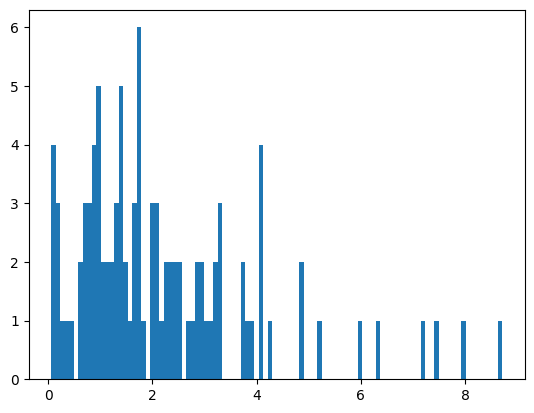

In [23]:
mmean = np.random.geometric(0.5, 10000)
devstd = np.random.uniform(0, 1, 10000)

plt.hist(np.random.normal(mmean, devstd), bins=100)
plt.show()